# Module 20: Pseudo-Random Number Generation

## Learning Objectives
By the end of this module you should be able to:
1. Explain why true randomness is difficult to generate and quantify with a correlation measure
2. Describe how a Linear Congruential Generator (LCG) produces pseudo-random numbers
3. Identify the role of the parameters $a$, $c$, $M$, and the seed $r_0$ in an LCG
4. Explain what a seed is and why it is needed for reproducibility
5. Verify that a pseudo-RNG produces uniformly distributed output using a histogram

---

## Background

When you call `np.random.randint(0, 2, 100)`, Python appears to produce numbers "at random" — but a computer is a deterministic machine. How is randomness possible?

The answer is **pseudo-random number generation**: a deterministic algorithm that produces a sequence of numbers that *looks* random by passing statistical tests, even though every value is fully determined by the previous one. The core idea is a recurrence relation:

$$r_{n+1} = (a \cdot r_n + c) \bmod M$$

This is called a **Linear Congruential Generator (LCG)**. The sequence is periodic with maximum period $M$ (under certain conditions on $a$, $c$, $M$). For practical use, $M$ is typically chosen to be very large (e.g., $2^{48}$), making the period astronomically long.

The starting value $r_0$ is called the **seed**. Different seeds produce different sequences — but the same seed always produces the same sequence, which is essential for reproducibility in scientific computing.

Before we look at the algorithm, we'll first appreciate *why* randomness is hard to fake by testing our own ability to generate random sequences.

---

## Section 0: Can Humans Generate Random Numbers?

A truly random binary sequence ($0$s and $1$s) should have no correlation between adjacent values. A useful measure is the **nearest-neighbor correlation**:

$$C = \frac{1}{N-1}\sum_{i=0}^{N-2} r_i \cdot r_{i+1}$$

For a perfectly random sequence of equal-probability $0$s and $1$s, the expected value of $C$ is $0.25$ (since $P(r_i=1) = P(r_{i+1}=1) = 0.5$ independently gives $P(r_i \cdot r_{i+1} = 1) = 0.25$).

- If you tend to **cluster** (0,0,0,1,1,1,...): $C$ drifts toward $0.5$
- If you tend to **alternate** (0,1,0,1,...): $C$ drifts toward $0$

> **Q0.1** — Run the cell below. The `correlation` function is already provided. Verify that `clustered` gives a value near $0.5$ and `alternating` gives a value near $0.0$. Does the output match expectations? Explain why each sequence produces that result.

> **Q0.2** — Enter your own list of 20 zeros and ones in `my_sequence` in the cell after, and compute its correlation. How close to $0.25$ can you get? What bias do you notice in your own choices?

In [16]:
import numpy as np

def correlation(rlist):
    """Nearest-neighbor correlation of a binary list."""
    res = 0
    k = 1
    for i in range(len(rlist) - k):
        res = res + rlist[i] * rlist[i + k]
    return res / (len(rlist) - 1)

# Clustered: long runs of 0s then 1s — correlation should be near 0.5
clustered   = [0]*10 + [1]*10
# Alternating: 0,1,0,1,... — correlation should be near 0.0
alternating = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]

print(f"Clustered   (expect ~0.5): {correlation(clustered):.4f}")
print(f"Alternating (expect ~0.0): {correlation(alternating):.4f}")

Clustered   (expect ~0.5): 0.4737
Alternating (expect ~0.0): 0.0000


In [17]:
# Sanity check: NumPy's RNG should average close to 0.25
rng = np.random.default_rng()
trials = [correlation(rng.integers(0, 2, 20)) for _ in range(10)]
print("NumPy RNG trials:", [f"{x:.4f}" for x in trials])
print(f"Mean over 10 trials: {np.mean(trials):.4f}  (expect ~0.25)")

NumPy RNG trials: ['0.3158', '0.3158', '0.2632', '0.3158', '0.0526', '0.1579', '0.0526', '0.3158', '0.3684', '0.1579']
Mean over 10 trials: 0.2316  (expect ~0.25)


In [18]:
# TODO: replace the list below with your own 20 zeros and ones
my_sequence = [0,1,1,1,0,0,1,1,1,1,0,0,0,0,1,1,0,0,1,0]

print(f"Your correlation: {correlation(my_sequence):.4f}")

Your correlation: 0.3158


*Your answers to Q0.1 and Q0.2:*

0.1 Yes the output matches the expected. THe cluster gives a value near 0.5 because it has a long line of 0's and 1's making the neighbour's correlation high because the next expected is a 0 in the 0 run and 1 in the 1 run.
However, in alternating never has two 1's or 0's next to each other, so every ajacent product is 0.

0.2 The sequenece still shows some short clusters of 1's and 0s rather than being perfectly balanced. Humans avoid long runs and sometimes create patterns so the results will drift from the 0.25

---

## Part 1: The Linear Congruential Generator

The LCG recurrence is:

$$r_{n+1} = (a \cdot r_n + c) \bmod M$$

The parameters are:
- $a$ — multiplier
- $c$ — increment
- $M$ — modulus (determines the range $[0, M)$ and the maximum period)
- $r_0$ — seed (initial value)

### Task 1 — Minimal LCG

> **Q1.1** — Complete `lcg_small` below using $a=4$, $c=1$, $M=9$, seed $r_0=3$. Print 20 values. What is the period of the sequence?

In [19]:
def lcg_small(size=20):
    a = 4
    c = 1
    M = 9
    r = 3          # fixed seed
    result = []
    for i in range(size):
        r = (a*r+c) % M  # TODO: apply the LCG recurrence
        result.append(r)
    return result

print(lcg_small(20))

[4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8, 6, 7, 2, 0, 1, 5, 3, 4, 8]


*Your answer to Q1.1:*

The period of the sequence is 9

### Task 2 — LCG with a large modulus

For practical use we need a much larger period. Choosing $M = 2^{48}$ and rescaling by $M$ gives pseudo-random floats in $[0, 1)$.

> **Q1.2** — Complete `lcg_large` with $a=123$, $c=11$, $M=2^{48}$, seed $r_0=3$. Use `r / M` to rescale. Plot 1000 values with `plt.plot(..., 'k.')`. Do the points look uniformly scattered?

> **Q1.3** — What determines the *range* of the output values? What determines the *maximum period* before the sequence repeats?

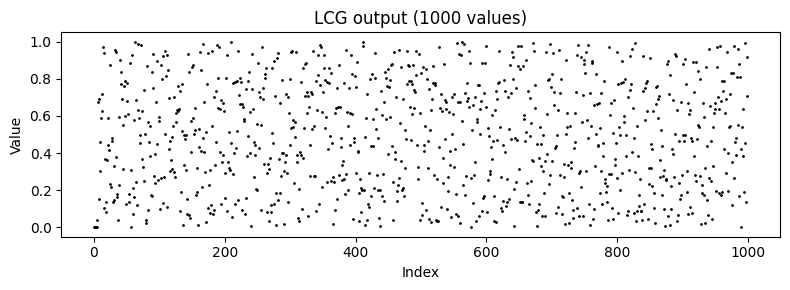

In [20]:
import matplotlib.pyplot as plt

def lcg_large(size=1000):
    a = 123
    c = 11
    M = 2**48
    r = 3          # fixed seed
    result = []
    for i in range(size):
        r = (a*r+c) % M  # TODO: LCG recurrence
        result.append(r / M)  # TODO: rescale to [0, 1)
    return result

values = lcg_large(1000)
plt.figure(figsize=(8, 3))
plt.plot(values, 'k.', ms=2)
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('LCG output (1000 values)')
plt.tight_layout()
plt.show()

*Your answers to Q1.2 and Q1.3:*

Q1.2 Yes the points look uniformily scattered

Q1.3 The range of the output values is determiend by the % M. And the maximum period is also determined by M since there are only M possible states.

---

## Part 2: Seeds and Reproducibility

With a fixed seed, `lcg_large` returns the **exact same sequence** every time — making the output deterministic, not random. To get a different sequence each run, we need a seed that changes.

A common trick is to use the current time: the microsecond component of the system clock (`datetime.now().microsecond`) changes with every run and is hard to predict.

> **Q2.1** — Complete `lcg_with_time_seed`: replace `r = 3` with `r = datetime.now().microsecond`. Run it twice and compare the first 5 output values. Are they the same?

> **Q2.2** — Why do NumPy and most scientific libraries let you *optionally* fix the seed (e.g., `rng = np.random.default_rng(seed=42)`)? When would you want a fixed seed vs a random one?

In [21]:
from datetime import datetime

def lcg_with_time_seed(size=10):
    a = 123
    c = 11
    M = 2**48
    r = datetime.now().microsecond  # TODO: use datetime.now().microsecond as the seed
    print(f'seed = {r}')
    result = []
    for i in range(size):
        r = (a * r + c) % M
        result.append(r / M)
    return result

print("Run 1:", lcg_with_time_seed(5))
print("Run 2:", lcg_with_time_seed(5))

seed = 916949
Run 1: [4.0069188145253065e-07, 4.928510145774112e-05, 0.006062067479341238, 0.7456342999590113, 0.7130188949584308]
seed = 917190
Run 2: [4.0079719454411133e-07, 4.9298054968005545e-05, 0.006063660761103762, 0.7458302736158018, 0.7371236547436588]


*Your answers to Q2.1 and Q2.2:*

2.1 The values between two run are really close

2.2 A fixed seed would be useful if you want to reproduce results exactly. Essential for debugging and testing. A random seed is useful when you want true variability across runs. Comparing differeing simulations and analyzing patterns.

---

## Part 3: Statistical Quality — Uniformity Test

A good pseudo-RNG should produce values that are **uniformly distributed** over its output range. We can check this visually with a histogram.

> **Q3.1** — Generate 100 000 values with `lcg_with_time_seed(100000)` and plot a histogram with `bins=50`. Does the distribution look flat (uniform)?

> **Q3.2** — Now do the same with `np.random.default_rng().random(100000)`. Compare the two histograms. What would a *non*-uniform histogram look like if the LCG had poor parameters?

seed = 286092


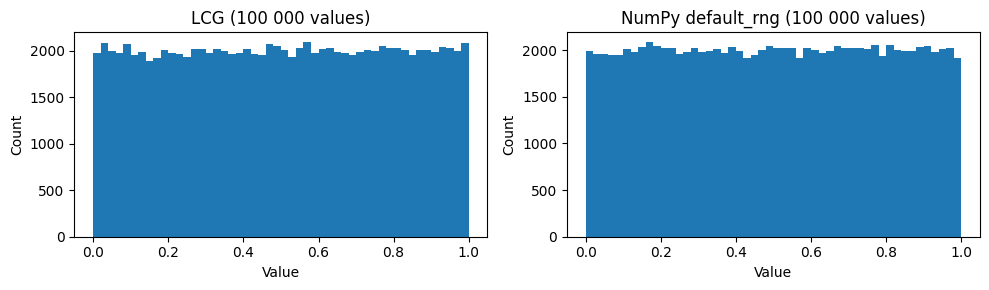

In [22]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# LCG histogram
lcg_vals = lcg_with_time_seed(100000)
ax1.hist(lcg_vals, bins=50)
ax1.set_xlabel('Value')
ax1.set_ylabel('Count')
ax1.set_title('LCG (100 000 values)')

# NumPy RNG histogram
rng = np.random.default_rng()
np_vals = rng.random(100000)
ax2.hist(np_vals, bins=50)
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')
ax2.set_title('NumPy default_rng (100 000 values)')

plt.tight_layout()
plt.show()

*Your answers to Q3.1 and Q3.2:*

3.1 Yes it is approximately flat

3.2 The default rng looks flatter than the LCG. A non uniform histogram would show some bins taller than others, clustering, and multiple peaks than just one uniform.

---

### Task 4 — Apply the correlation test to the LCG

We started this module by measuring the correlation of human-generated sequences. Now apply the same test to our LCG.

> **Q3.3** — Convert 20 LCG values to binary by rounding to 0 or 1 (use `[round(v) for v in lcg_large(20)]`), then compute and print the correlation. Repeat 10 times. Do the values cluster around 0.25 as expected?

> **Q3.4** — Does a correlation near 0.25 prove the sequence is truly random? What other tests might a cryptographer apply?

In [38]:
# Run 10 correlation trials using the LCG
for trial in range(10):
    binary = [round(v) for v in lcg_with_time_seed(20)]  # TODO: generate 20 LCG values and round them to 0 or 1
    print(f"Trial {trial+1}: {correlation(binary):.4f}")
    average = correlation(binary)
average = average/10
print(f"Average correlation: {average:.4f}")

seed = 776034
Trial 1: 0.2105
seed = 776358
Trial 2: 0.0526
seed = 776379
Trial 3: 0.1053
seed = 776398
Trial 4: 0.4737
seed = 776414
Trial 5: 0.3684
seed = 776430
Trial 6: 0.2105
seed = 776446
Trial 7: 0.3684
seed = 776462
Trial 8: 0.3158
seed = 776478
Trial 9: 0.3684
seed = 776494
Trial 10: 0.5789
Average correlation: 0.0579


*Your answers to Q3.3 and Q3.4:*

3.3 No the average correlation is not near 0.25 as expected but instead of 20 values a larger number was used then it might show clustering around 0.25

3.4 No a correlation near 0.25 does not prove the sequence is truly random. It only checks one propertly but other properties such as frequency distributions, run lengths, and chi squared test can also be used.

---

## Summary Questions

> **S1** — Describe in one paragraph how a Linear Congruential Generator works. Identify all four parameters and explain the role of each.

> **S2** — Why is it called a *pseudo*-random number generator rather than a true RNG? Give one example of a physical process that could serve as a true RNG.

> **S3** — Suppose a colleague sets the seed to `42` at the top of every simulation. What is the advantage? What is the disadvantage for, say, bootstrapping confidence intervals over many independent runs?

> **S4** — The LCG recurrence produces integers in $[0, M)$. How would you modify `lcg_large` to produce random integers in the range $[a, b)$ (like `rng.integers(a, b, N)`)?

*Your answers:*

**S1:** A LCG produces a sequence of pseudo random integers using recurrence, it uses the formula (a*r + c) % M
a - multiplier scales the value
c - increment shifts the value
M = modulus it bounds the output 
r = seed of the generator

Each new value depends on the previous one and repeats M steps.

**S2:** It is called pseudo random because the numbers are generated by a deterministic algorithm, not by a physical random process. The output appears random by the same seeds produces the same sequenece every time. One example of true RNG is the movements of sub atomic particles such as electrons and photons

**S3:** The advantages of a fixed seed like 42 makes every run reproducible, so the results can be debugged, compared, and shared with others. The disadvantaged for bootstrapping many runs is that those runs are no longer independs random samples because they use the same underlying seed. This can cause bias in confidence intervals and various other analysis.

**S4:** To produce intergers in rage [a, b] mpa the lCG output form [0, M] into the smaller range. After generating the r from [0, M] shift the values to fit into the [a,b] range and reduce any values that exceed this range.